<a href="https://colab.research.google.com/github/TomaszPasnikowski/ML_2026_homeworks/blob/main/LAB2_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import matplotlib

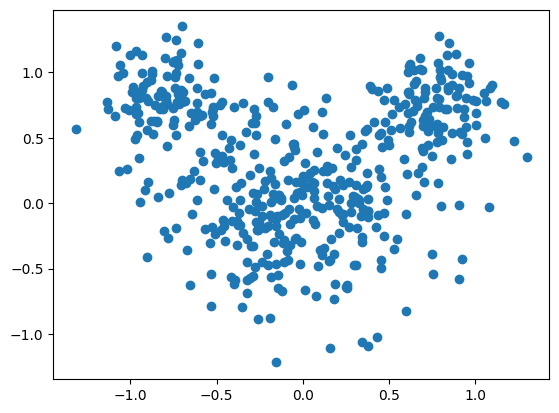

In [2]:
# ----------------------------------------------------------------------
# SECTION 1: Generate the "mouse" dataset
# ----------------------------------------------------------------------
np.random.seed(0)  # for reproducibility

# 1) 300 points from N([0, 0], [[0.16, 0],[0, 0.16]])
mean1 = np.array([0.0, 0.0])
cov1 = np.array([[0.16, 0.0],
                 [0.0,  0.16]])
data1 = np.random.multivariate_normal(mean1, cov1, 300)

# 2) 100 points from N([0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean2 = np.array([0.8, 0.8])
cov2 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data2 = np.random.multivariate_normal(mean2, cov2, 100)

# 3) 100 points from N([-0.8, 0.8], [[0.04, 0],[0, 0.04]])
mean3 = np.array([-0.8, 0.8])
cov3 = np.array([[0.04, 0.0],
                 [0.0,  0.04]])
data3 = np.random.multivariate_normal(mean3, cov3, 100)

# Combine all data
data_X = np.vstack([data1, data2, data3])
N, d = data_X.shape  # should be (500, 2)

plt.scatter(data_X[:, 0], data_X[:, 1])
plt.show()

## **Primary Question**

**How can we visualize the *decision boundary* for attributing a *new* (unlabeled) point to one of the GMM clusters?**  

In other words, given a 2D data distribution modeled by EM, think of a way to clearly show (on a plot) *which* cluster a point would be assigned to (or which cluster has the highest responsibility (posterior probability) for that point)?  

The plot should comprehensively cover the entire visible region, ensuring that for any point on the plot, it is immediately evident which cluster it would belong to. You can plot **lines** separating clusters or use a **color map** showing each point's "most likely cluster" (use at least 1000 points).

You can illustrate your approach with **the same** 2D dataset that we used in class, or you can find another suitable 2D dataset, it's up to you. Note however, that having 3 clusters enhances the clarity of the visualization—while 2 clusters result in overly simple boundaries, using 4 or more clusters can make the entire plot difficult to interpret. Try to choose a dataset with 3 clusters.

Discuss any irregularities observed in the resulting plot. If a decision boundary suggests that a region should be attributed to a cluster in a counterintuitive way (we saw it in class!), provide an explanation for why this might occur. It may be also an indication you have a bug in your code.

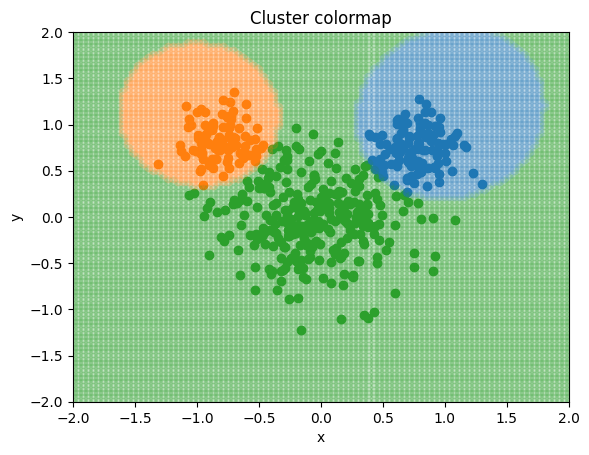

In [3]:
cmap = matplotlib.colormaps["tab10"]

# Fitting model
model = GaussianMixture(n_components= 3, covariance_type= "full", random_state= 42)
model.fit(data_X)

# Predicting training data
predictions = model.predict(data_X)

result = pd.DataFrame(data= {"x" : data_X[:,0],
                            "y" : data_X[:,1],
                            "prediction" : predictions})

# Visualizing training data predictions
for label in result.prediction.unique():
    plt.scatter(result[result.prediction == label]["x"], result[result.prediction == label]["y"], color= cmap(label))

#plt.show()
# Predicting the whole surface
N = 100

x_linspace = np.linspace(-2, 2, num= N)
y_linspace = np.linspace(-2, 2, num= N)


x_grid, y_grid = np.meshgrid(x_linspace, y_linspace)
grid = np.dstack([x_grid.ravel(), y_grid.ravel()])[0]

grid_predictions= model.predict(grid)
grid_result = pd.DataFrame(data= {"x" : grid[:,0],
                            "y" : grid[:,1],
                            "prediction" : grid_predictions})

# Visualizing grid predictions
for label in grid_result.prediction.unique():
    plt.scatter(grid_result[grid_result.prediction == label]["x"], grid_result[grid_result.prediction == label]["y"], color= cmap(label), alpha= 0.15)

plt.xlim((-2, 2))
plt.ylim((-2, 2))
plt.title("Cluster colormap")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


The result show that the Mixed Gaussian Clustering divide the plane into 3 areas where the regions of yellow and blue clusters are elipsoid-shaped and the green cluster fills the rest of the space. This is due to the fact that the model predicts the cluster for each point $x$ according to the formula:

$$C(x) = arg max_k(\pi_k \cdot f_k(x))$$

Where $f_k$ is the estimated density of the distribution of cluster $k$ and $\pi_k$ is the estimated weight of that cluster.\
As we can see below, both the covariance matrix and the weight of the green (third) cluster is the largest, so when we take a point distant from all of the cluster centres, the model will predict that cluster.

In [4]:
print("weights:\n", model.weights_)
print("means:\n", model.means_)
print("covariances:\n", model.covariances_)


weights:
 [0.21642398 0.19982281 0.58375321]
means:
 [[ 0.76685767  0.74738792]
 [-0.79619442  0.81734276]
 [-0.05172985 -0.02233533]]
covariances:
 [[[ 0.03448645  0.00195799]
  [ 0.00195799  0.04676817]]

 [[ 0.03096687 -0.00175913]
  [-0.00175913  0.04101211]]

 [[ 0.15485967 -0.00902081]
  [-0.00902081  0.15592878]]]


In [5]:
"""
A working example to ilustrate the prediction of point (2,2).
As we can see, the likelihood of the third (green) cluster is the largest even though, its center is further from that of the first cluster.
Note that the differences are substantial even without taking the cluster weights into account.
"""

from scipy.stats import multivariate_normal

point = (2, 2)
p1 = multivariate_normal(model.means_[0], model.covariances_[0]).pdf(point)
p2 = multivariate_normal(model.means_[1], model.covariances_[1]).pdf(point)
p3 = multivariate_normal(model.means_[2], model.covariances_[2]).pdf(point)

print(p1, p2, p3)

3.2711471590909173e-16 1.8708121928261646e-64 4.990285426729399e-13


## **Secondary Question**

**If we *didn't know* the number of clusters in advance, how could we decide on a suitable $K$ for the clustering algorithm?**  

You would need an evaluation metrics, right? Experiment with inertia and silhoutte scores (and other metrics, if you'd like) and show the resulting plots.

You can illustrate your approach with **the same** dataset as in the primary question by trying different values of $K$. Or you can find another suitable dataset, it's up to you. Note, that the dataset doesn't need to be 2D in this task.

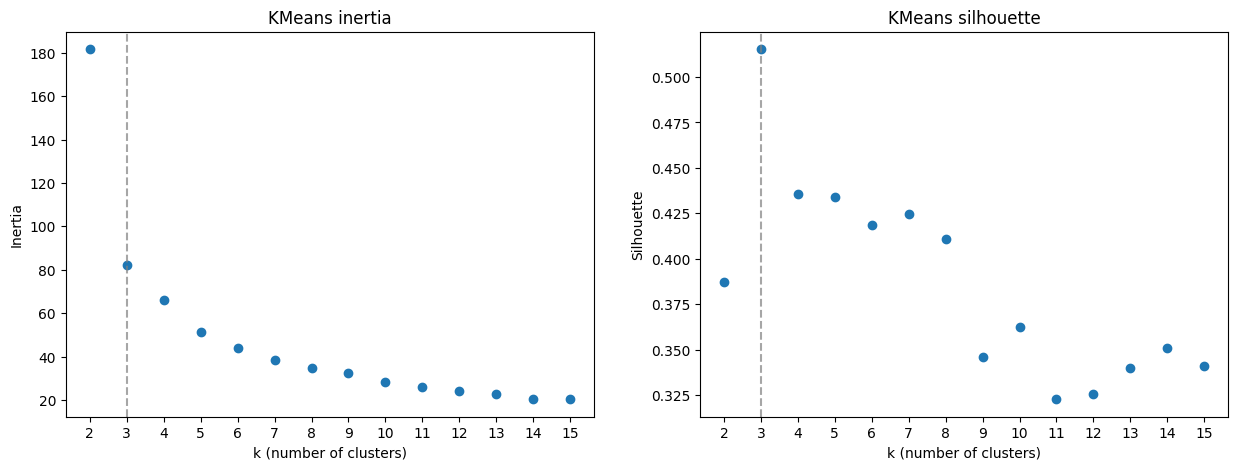

In [6]:
from sklearn.cluster import  KMeans
from sklearn.metrics import silhouette_score

inertia = list()
silhouette = list()

for k in range(2, 16):
    km = KMeans(k)
    km.fit(data_X)
    inertia.append(km.inertia_)
    pred = km.predict(data_X)
    silhouette.append(silhouette_score(data_X, pred))

fig, axs = plt.subplots(1, 2, figsize= (15,5))


axs[0].scatter(list(range(2, 16)), inertia)
axs[0].set_xticks(list(range(2, 16)))
axs[0].set_title("KMeans inertia")
axs[0].set_xlabel("k (number of clusters)")
axs[0].axvline(x= 3, color= "gray", linestyle= "dashed", alpha= 0.7)
axs[0].set_ylabel("Inertia")

axs[1].scatter(list(range(2, 16)), silhouette)
axs[1].set_xticks(list(range(2, 16)))
axs[1].axvline(x= 3, color= "gray", linestyle= "dashed", alpha= 0.7)
axs[1].set_title("KMeans silhouette")
axs[1].set_xlabel("k (number of clusters)")
axs[1].set_ylabel("Silhouette")


plt.show()


The two meauseres we are considering as criterions for choosing the right number of clusters are inertia and the silhouette score.


Inertia is a sum of squared distances of all the points from their cluster centres, so it is natural that it will always decrease with bigger $k$ parameters. Nonetheless is still useful, because one can evaluate the performance of clustering by looking at the sizes of the inertia drops as the number of cluster increases. When a significant cluster is added to the analysis, the inertia value should drop substantially, whereas adding an insignificant cluster will only reduce it by small amount because the distances from the centres of points assigned to the new cluster were probably low to begin with. Thus a good way to choose the best $k$ parameter is perform the clustering for many values of $k$ and look for the "kink" point on the inertia plot. In this case, the plot suggests that the optimal number of clusters is $3$ because it's inertia is significantly lower than for $k = 2$ and also introducing additional clusters only lowers it by a small amount.


The silhouette-score averages the difference between the average distance between a point and all the points from its cluster and the average distance between a point and all the points from the nearest cluster (the difference is then divided by a max of those two). This metric is normalized to $[-1,1]$ where values close to $1$ mean good clustering (as all the points are close to each other within clusters and far from other clusters) and values close to $-1$ mean poor clustering (as it means that a point is closer to a neighbouring cluster that to its own). In this case the highest silhouette-score is achieved also for $3$ clusters, which confirms that it is the optimal choice for this task.